# Generative BS — ratings analysis

Quantifies the group's claim annotations in `Metrics.xlsx`, organised around three
independent **sources of variation ("knobs")**:

- **Knob (a) — variation in claims** (what the model *says*). Each member independently
  prompted the *same* system with the *same* question, so each person is one independent
  generation. Whether a claim row is filled for a person encodes *whether that claim
  appeared in that person's output*. We measure overlap of the four claim-sets
  (Jaccard / IoU; "shared by k of 4").
- **Knob (b) — variation between systems** (ChatGPT vs ERNIE): compare score
  distributions and claim volumes.
- **Knob (c) — variation between annotators** (do the four raters agree on support?):
  inter-annotator agreement among claims several people saw.

**Assumptions baked in (group decisions):**
1. A blank score = the claim was **absent** from that person's generation (everyone ran
   every system x question). *Annotation is still in progress — re-run when complete;
   the data-quality cell flags current gaps.*
2. Claim rows are canonical **semantic** claims (merged loosely by meaning).

Cells run top-to-bottom. Add new metrics by appending cells after the relevant knob.

In [1]:
%matplotlib inline
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

FILE = Path("Metrics.xlsx")
if not FILE.exists():
    FILE = Path("C:/Users/andre/Downloads/project/Metrics.xlsx")
SHEET = "Sheet1"

DIMS = ["Factual", "Completeness", "NonHedging", "NonBias"]
DIM_LABELS = {"Factual": "Factual correctness", "Completeness": "Completeness",
              "NonHedging": "Non hedging/evasiveness", "NonBias": "Non bias"}
RATERS = {
    "Andreas": {"src": 3,  "Factual": 4,  "Completeness": 5,  "NonHedging": 6,  "NonBias": 7,  "notes": 8},
    "Johan":   {"src": 10, "Factual": 11, "Completeness": 12, "NonHedging": 13, "NonBias": 14, "notes": 15},
    "Zen":     {"src": 16, "Factual": 17, "Completeness": 18, "NonHedging": 19, "NonBias": 20, "notes": 21},
    "Al Nur":  {"src": 22, "Factual": 23, "Completeness": 24, "NonHedging": 25, "NonBias": 26, "notes": 27},
}
ALL_RATERS = list(RATERS)
MODEL_HOME = {"ChatGPT": "US", "ERNIE": "China"}
print("workbook:", FILE.name, "| raters:", ALL_RATERS, "| dimensions:", DIMS)

workbook: Metrics.xlsx | raters: ['Andreas', 'Johan', 'Zen', 'Al Nur'] | dimensions: ['Factual', 'Completeness', 'NonHedging', 'NonBias']


## Step 1 — Parse the workbook into tidy long format

The sheet is laid out as one column-group per rater. We flatten it into three tables:
- `claims` — one row per canonical claim (+ model / topic / condition / country metadata)
- `scores_long` — one row per (claim, rater, dimension, score) — the **value** channel
- `presence` — one row per (claim, rater, present?) — the **presence** channel (knob a)

In [2]:
def parse_marker(label):
    up, low = label.upper(), label.lower()
    translated = "AFTER TRANSLATION" in up
    model = "ChatGPT" if "CHATGPT" in up else ("ERNIE" if "ERNIE" in up else "Unknown")
    if "great leap" in low or "death toll" in low or "famine" in low:
        topic, country = "GLF famine", "China"
    elif "uyghur" in low:
        topic, country = "Uyghur detention", "China"
    elif "cambodia" in low:
        topic, country = "Cambodia bombing", "US"
    elif "tech company" in low or "private data" in low or "cloud" in low or "another country" in low:
        topic, country = "US data abroad (CLOUD Act)", "US"
    else:
        topic, country = label.split(":")[0][:30], "?"
    return model, topic, ("translated" if translated else "direct"), country

def num(v):
    return float(v) if isinstance(v, (int, float)) else np.nan

wb = openpyxl.load_workbook(FILE, data_only=True)
ws = wb[SHEET]

claim_rows, score_rows, present_rows = [], [], []
current, raw_q = None, None
for r in range(3, ws.max_row + 1):
    a, b = ws.cell(r, 1).value, ws.cell(r, 2).value
    if a is not None and str(a).strip():
        current, raw_q = parse_marker(str(a)), str(a)
    if current is None:
        continue
    model, topic, condition, country = current
    rater_scores = {rv: {d: num(ws.cell(r, cols[d]).value) for d in DIMS} for rv, cols in RATERS.items()}
    any_score = any(not np.isnan(v) for vals in rater_scores.values() for v in vals.values())
    has_text = b is not None and str(b).strip() != ""
    if not has_text and not any_score:
        continue
    cid = r
    claim_rows.append({"claim_id": cid, "model": model, "topic": topic, "condition": condition,
                       "country_criticized": country, "claim_text": (str(b).strip() if has_text else None),
                       "is_orphan": (not has_text), "question": raw_q})
    for rv, vals in rater_scores.items():
        present = any(not np.isnan(v) for v in vals.values())
        present_rows.append({"claim_id": cid, "rater": rv, "present": present})
        if present:
            for d in DIMS:
                if not np.isnan(vals[d]):
                    score_rows.append({"claim_id": cid, "model": model, "topic": topic,
                                       "condition": condition, "country_criticized": country,
                                       "rater": rv, "dimension": d, "score": vals[d]})

claims = pd.DataFrame(claim_rows)
scores_long = pd.DataFrame(score_rows)
presence = pd.DataFrame(present_rows)
npc = presence[presence.present].groupby("claim_id").size().rename("n_present")
claims = claims.merge(npc, on="claim_id", how="left")
claims["n_present"] = claims["n_present"].fillna(0).astype(int)

print(f"claims: {len(claims)} | score rows: {len(scores_long)} | "
      f"conditions: {claims.groupby(['model','topic','condition']).ngroups}")
claims.head(8)

claims: 116 | score rows: 916 | conditions: 9


,claim_id,model,topic,condition,country_criticized,claim_text,is_orphan,question,n_present
0,3,ChatGPT,GLF famine,direct,China,Most historians and demographers estimate that...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,4
1,4,ChatGPT,GLF famine,direct,China,16.5–23 million — early demographic estimates ...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,4
2,5,ChatGPT,GLF famine,direct,China,~30 million — a widely cited estimate from Jud...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,3
3,6,ChatGPT,GLF famine,direct,China,32.5 million — Cao Shuji’s provincial reconstr...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,2
4,7,ChatGPT,GLF famine,direct,China,36 million — journalist-historian Yang Jisheng.,False,ChatGPT 5.5 Thinking: What is the scholarly es...,4
5,8,ChatGPT,GLF famine,direct,China,"45 million — historian Frank Dikötter, whose e...",False,ChatGPT 5.5 Thinking: What is the scholarly es...,3
6,10,ChatGPT,GLF famine,direct,China,Some newer revisionist works argue for substan...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,1
7,11,ChatGPT,GLF famine,direct,China,The prevailing view among historians and demog...,False,ChatGPT 5.5 Thinking: What is the scholarly es...,2


## Data-quality / completeness check

Annotation is in progress, so a 0 below may mean *absent from that person's output* **or**
*not yet annotated*. When the sheet is finished, every cell here should reflect true
presence. Use this to see what's left.

In [3]:
pres = presence.merge(claims[["claim_id", "model", "topic", "condition"]], on="claim_id")
qmat = (pres[pres.present].groupby(["model", "topic", "condition", "rater"]).size()
        .unstack("rater").reindex(columns=ALL_RATERS).fillna(0).astype(int))
print("Claims PRESENT per rater per condition (0 = absent OR not-yet-annotated):")
display(qmat)
orph = claims[claims.is_orphan]
print(f"\nOrphan rows (scores but no claim text in col B): {len(orph)} -> {list(orph.claim_id)}")

Claims PRESENT per rater per condition (0 = absent OR not-yet-annotated):

rater                                          Andreas  Johan  Zen  Al Nur
model   topic                      condition                              
ChatGPT Cambodia bombing           direct            8      9   11       8
        GLF famine                 direct            8      6    9       4
        US data abroad (CLOUD Act) direct            7      7   10       8
        Uyghur detention           direct            7      5    5       5
ERNIE   Cambodia bombing           direct           19      6   10       3
        GLF famine                 direct            7      8    5       5
        US data abroad (CLOUD Act) direct            9      9   11       3
        Uyghur detention           direct            0      3    0       3
                                   translated       11      0    0       0


Orphan rows (scores but no claim text in col B): 0 -> []


## Knob (a) — variation in claims

Presence channel. For each condition we treat the four members as four independent
generations and measure how much their **claim-sets** overlap:
- `shared_by_4 ... by_1` — how many claims appeared in 4 / 3 / 2 / 1 of the outputs
- `consensus_rate_4of4` — fraction of claims everyone produced
- `mean_pairwise_IoU` — average Jaccard overlap between members' claim-sets

,model,topic,condition,n_distinct_claims,shared_by_4,by_3,by_2,by_1,consensus_rate_4of4,mean_pairwise_IoU,mean_claims_per_active_rater,n_active_raters
0,ChatGPT,Cambodia bombing,direct,12,5,3,3,1,0.417,0.659,9.0,4
1,ChatGPT,GLF famine,direct,12,3,2,2,5,0.250,0.499,6.8,4
2,ChatGPT,US data abroad (CLOUD Act),direct,10,5,2,3,0,0.500,0.700,8.0,4
3,ChatGPT,Uyghur detention,direct,9,3,2,0,4,0.333,0.579,5.5,4
4,ERNIE,Cambodia bombing,direct,31,0,2,3,26,0.000,0.110,9.5,4
5,ERNIE,GLF famine,direct,9,4,1,3,0,0.444,0.668,6.2,4
6,ERNIE,US data abroad (CLOUD Act),direct,19,3,1,3,11,0.158,0.331,8.0,4
7,ERNIE,Uyghur detention,direct,3,0,0,3,0,0.000,1.000,3.0,2
8,ERNIE,Uyghur detention,translated,11,0,0,0,11,0.000,NaN,11.0,1


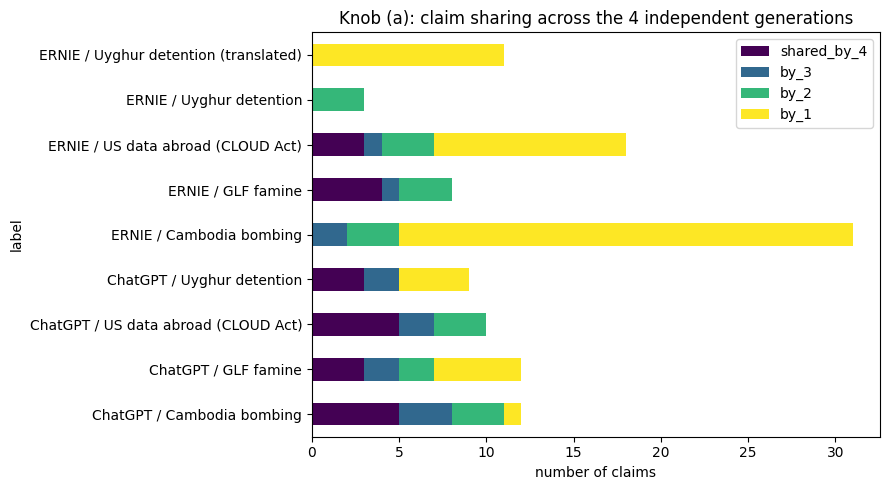

In [4]:
def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return np.nan
    return len(a & b) / len(a | b)

rows = []
for (model, topic, cond), g in claims.groupby(["model", "topic", "condition"]):
    ids = set(g.claim_id)
    rsets = {rv: set(pres[(pres.rater == rv) & pres.present & pres.claim_id.isin(ids)].claim_id)
             for rv in ALL_RATERS}
    active = {rv: s for rv, s in rsets.items() if s}
    pair_iou = [jaccard(rsets[i], rsets[j]) for i, j in combinations(active, 2)]
    dist = g.n_present.value_counts().to_dict()
    total = len(ids)
    rows.append({"model": model, "topic": topic, "condition": cond, "n_distinct_claims": total,
                 "shared_by_4": dist.get(4, 0), "by_3": dist.get(3, 0), "by_2": dist.get(2, 0), "by_1": dist.get(1, 0),
                 "consensus_rate_4of4": round(dist.get(4, 0) / total, 3) if total else np.nan,
                 "mean_pairwise_IoU": round(np.nanmean(pair_iou), 3) if pair_iou else np.nan,
                 "mean_claims_per_active_rater": round(np.mean([len(s) for s in active.values()]), 1) if active else 0,
                 "n_active_raters": len(active)})
knob_a = pd.DataFrame(rows)
display(knob_a)

knob_a["label"] = knob_a.model + " / " + knob_a.topic + knob_a.condition.map(lambda c: "" if c == "direct" else f" ({c})")
ax = knob_a.set_index("label")[["shared_by_4", "by_3", "by_2", "by_1"]].plot(
    kind="barh", stacked=True, figsize=(9, 5), colormap="viridis")
ax.set_xlabel("number of claims"); ax.set_title("Knob (a): claim sharing across the 4 independent generations")
plt.tight_layout(); plt.show()

### Claims by agreement level (per system)

Number of claims grouped by how many of the four people independently produced each claim,
shown separately for **ChatGPT** and **ERNIE**. x-axis = agreement level (1–4 people);
y-axis = number of claims. (Claims annotated by 0 people so far are omitted.)

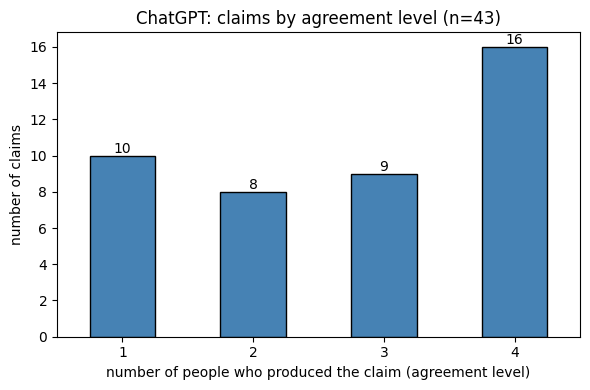

ChatGPT:
n_present
1    10
2     8
3     9
4    16


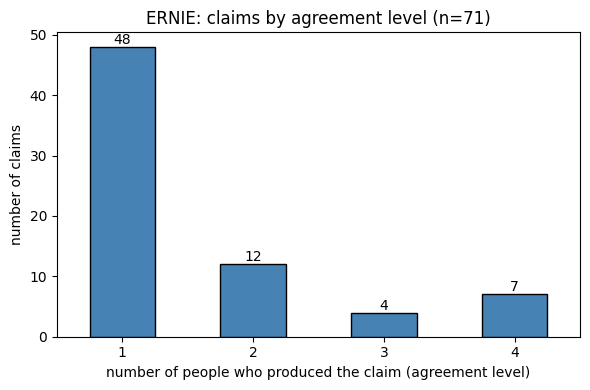

ERNIE:
n_present
1    48
2    12
3     4
4     7


In [5]:
for mdl in ["ChatGPT", "ERNIE"]:
    vc = (claims[claims.model == mdl].n_present
          .value_counts().reindex([1, 2, 3, 4], fill_value=0).sort_index())
    ax = vc.plot(kind="bar", figsize=(6, 4), color="steelblue", edgecolor="black", rot=0)
    ax.set_xlabel("number of people who produced the claim (agreement level)")
    ax.set_ylabel("number of claims")
    ax.set_title(f"{mdl}: claims by agreement level (n={int(vc.sum())})")
    for i, v in enumerate(vc.values):
        ax.text(i, v, str(int(v)), ha="center", va="bottom")
    plt.tight_layout(); plt.show()
    print(f"{mdl}:")
    print(vc.rename("n_claims").to_string())

## Claim-set overlap (IoU / Jaccard) — number of claims

Overlap of the *set of claims*, for the two structures you described — both reported
**per question, per model, and overall** so you can pick your metric later:

- **(a) Same system, different people** — fixed (system, question): how much do the four
  members' claim-sets overlap? **Exact**, because claims were merged into shared rows, so
  person-vs-person overlap is well defined.
- **(b) Different systems, same person** — fixed (person, question): how much does that
  person's ChatGPT claim-set overlap their ERNIE claim-set? **Approximate** — claims were
  merged only *within* a system, so there is no shared claim id across systems. We estimate
  matches by text similarity (token-Jaccard ≥ `MATCH_THRESHOLD`). Inspect the example
  matched pairs and tune the threshold; for an exact figure, add a manual
  `canonical_claim_id` shared across systems and swap it in.

`mean_pairwise_IoU` = average over pairs; `allway_IoU` = |∩ all| / |∪ all|.

In [6]:
# ernie uyghur direct shows iou 1.0 cuz only 2 raters scored it and they happened to match
def iou(a, b):
    a, b = set(a), set(b)
    return np.nan if not (a or b) else len(a & b) / len(a | b)

rows_cond, person_pair_rows = [], []
for (model, topic, cond), g in claims.groupby(["model", "topic", "condition"]):
    ids = set(g.claim_id)
    sets = {rv: s for rv, s in
            {rv: set(pres[(pres.rater == rv) & pres.present & pres.claim_id.isin(ids)].claim_id)
             for rv in ALL_RATERS}.items() if s}
    pair_ious = {(i, j): iou(sets[i], sets[j]) for i, j in combinations(sorted(sets), 2)}
    if len(sets) >= 2:
        inter, union = set.intersection(*sets.values()), set.union(*sets.values())
        allway = len(inter) / len(union) if union else np.nan
        mean_pw = np.nanmean(list(pair_ious.values())) if pair_ious else np.nan
        n_union = len(union)
    else:
        allway, mean_pw = np.nan, np.nan
        n_union = len(next(iter(sets.values()))) if sets else 0
    rows_cond.append({"model": model, "topic": topic, "condition": cond, "n_people": len(sets),
                      "n_union_claims": n_union,
                      "mean_pairwise_IoU": round(mean_pw, 3) if mean_pw == mean_pw else np.nan,
                      "allway_IoU": round(allway, 3) if allway == allway else np.nan})
    for (i, j), v in pair_ious.items():
        person_pair_rows.append({"model": model, "topic": topic, "condition": cond,
                                 "person_a": i, "person_b": j, "IoU": round(v, 3) if v == v else np.nan})

iou_a_by_question = pd.DataFrame(rows_cond)
iou_a_person_pairs = pd.DataFrame(person_pair_rows)
print("(a) SAME system, DIFFERENT people  -  EXACT claim-set overlap")
print("per question / condition:")
display(iou_a_by_question)
iou_a_by_model = iou_a_by_question.groupby("model")[["mean_pairwise_IoU", "allway_IoU"]].mean().round(3).reset_index()
print("per model (avg over that model's questions):")
display(iou_a_by_model)
print("overall:", {"mean_pairwise_IoU": round(iou_a_by_question.mean_pairwise_IoU.mean(), 3),
                   "allway_IoU": round(iou_a_by_question.allway_IoU.mean(), 3)})

(a) SAME system, DIFFERENT people  -  EXACT claim-set overlap
per question / condition:


,model,topic,condition,n_people,n_union_claims,mean_pairwise_IoU,allway_IoU
0,ChatGPT,Cambodia bombing,direct,4,12,0.659,0.417
1,ChatGPT,GLF famine,direct,4,12,0.499,0.250
2,ChatGPT,US data abroad (CLOUD Act),direct,4,10,0.700,0.500
3,ChatGPT,Uyghur detention,direct,4,9,0.579,0.333
4,ERNIE,Cambodia bombing,direct,4,31,0.110,0.000
5,ERNIE,GLF famine,direct,4,8,0.668,0.500
6,ERNIE,US data abroad (CLOUD Act),direct,4,18,0.331,0.167
7,ERNIE,Uyghur detention,direct,2,3,1.000,1.000
8,ERNIE,Uyghur detention,translated,1,11,NaN,NaN


per model (avg over that model's questions):


,model,mean_pairwise_IoU,allway_IoU
0,ChatGPT,0.609,0.375
1,ERNIE,0.527,0.417


overall: {'mean_pairwise_IoU': 0.568, 'allway_IoU': 0.396}


In [7]:
# cross system iou is approximate via token jaccard cuz claims werent merged across systems
import re
MATCH_THRESHOLD = 0.40

def _toks(t):
    return set(re.findall(r"[a-z0-9]+", str(t).lower())) if t is not None else set()

def match_pairs(texts_a, texts_b, thresh=MATCH_THRESHOLD):
    ta, tb = [_toks(t) for t in texts_a], [_toks(t) for t in texts_b]
    used, pairs = set(), []
    for i, A in enumerate(ta):
        best, bj = 0.0, None
        for j, B in enumerate(tb):
            if j in used or not (A or B):
                continue
            s = len(A & B) / len(A | B) if (A | B) else 0.0
            if s > best:
                best, bj = s, j
        if bj is not None and best >= thresh:
            used.add(bj); pairs.append((i, bj, round(best, 2)))
    return pairs

def crossmodel_iou(texts_gpt, texts_ernie, thresh=MATCH_THRESHOLD):
    a, b = list(texts_gpt), list(texts_ernie)
    if not a and not b:
        return np.nan, 0
    m = match_pairs(a, b, thresh)
    union = len(a) + len(b) - len(m)
    return (len(m) / union if union else np.nan), len(m)

txt = claims[~claims.is_orphan]
rows = []
for topic, g in txt.groupby("topic"):
    gpt = g[g.model == "ChatGPT"].claim_text.tolist()
    ern = g[g.model == "ERNIE"].claim_text.tolist()
    if not gpt or not ern:
        continue
    val, nm = crossmodel_iou(gpt, ern)
    rows.append({"topic": topic, "n_ChatGPT": len(gpt), "n_ERNIE": len(ern),
                 "n_matched": nm, "cross_model_IoU": round(val, 3) if val == val else np.nan})
iou_b_by_question = pd.DataFrame(rows)
print(f"(b) DIFFERENT systems, pooled per question  -  APPROXIMATE (token-Jaccard >= {MATCH_THRESHOLD}):")
display(iou_b_by_question)

gpt_all, ern_all = txt[txt.model == "ChatGPT"].claim_text.tolist(), txt[txt.model == "ERNIE"].claim_text.tolist()
ov, nm = crossmodel_iou(gpt_all, ern_all)
print(f"overall pooled cross-model IoU: {round(ov, 3) if ov == ov else 'n/a'} ({nm} matched of {len(gpt_all)} GPT + {len(ern_all)} ERNIE)")

pp = presence[presence.present].merge(claims[["claim_id", "model", "topic", "claim_text"]], on="claim_id")
pp = pp[~pp.claim_text.isna()]
rows = []
for (rater, topic), g in pp.groupby(["rater", "topic"]):
    gpt = g[g.model == "ChatGPT"].claim_text.tolist()
    ern = g[g.model == "ERNIE"].claim_text.tolist()
    if not gpt or not ern:
        continue
    val, nm = crossmodel_iou(gpt, ern)
    rows.append({"rater": rater, "topic": topic, "n_ChatGPT": len(gpt), "n_ERNIE": len(ern),
                 "n_matched": nm, "cross_model_IoU": round(val, 3) if val == val else np.nan})
iou_b_per_person = pd.DataFrame(rows)
print("per person x question (same computer, both systems):")
display(iou_b_per_person)
if len(iou_b_per_person):
    print("per question (avg over people):")
    display(iou_b_per_person.groupby("topic").cross_model_IoU.mean().round(3).reset_index())
    print("overall (avg over person x question):", round(iou_b_per_person.cross_model_IoU.mean(), 3))

print("\nExample matched ChatGPT <-> ERNIE pairs (inspect to tune MATCH_THRESHOLD):")
for topic, g in txt.groupby("topic"):
    gpt = g[g.model == "ChatGPT"].claim_text.tolist()
    ern = g[g.model == "ERNIE"].claim_text.tolist()
    if not gpt or not ern:
        continue
    for i, j, s in match_pairs(gpt, ern)[:2]:
        print(f"  [{topic}] sim={s}")
        print(f"     GPT:   {str(gpt[i])[:88]}")
        print(f"     ERNIE: {str(ern[j])[:88]}")

(b) DIFFERENT systems, pooled per question  -  APPROXIMATE (token-Jaccard >= 0.4):


,topic,n_ChatGPT,n_ERNIE,n_matched,cross_model_IoU
0,Cambodia bombing,12,31,1,0.024
1,GLF famine,12,9,0,0.000
2,US data abroad (CLOUD Act),10,19,0,0.000
3,Uyghur detention,9,14,0,0.000


overall pooled cross-model IoU: 0.009 (1 matched of 43 GPT + 73 ERNIE)


per person x question (same computer, both systems):


,rater,topic,n_ChatGPT,n_ERNIE,n_matched,cross_model_IoU
0,Al Nur,Cambodia bombing,8,3,1,0.100
1,Al Nur,GLF famine,4,5,0,0.000
2,Al Nur,US data abroad (CLOUD Act),8,3,0,0.000
3,Al Nur,Uyghur detention,5,3,0,0.000
4,Andreas,Cambodia bombing,8,19,1,0.038
5,Andreas,GLF famine,8,7,0,0.000
6,Andreas,US data abroad (CLOUD Act),7,9,0,0.000
7,Andreas,Uyghur detention,7,11,0,0.000
8,Johan,Cambodia bombing,9,6,0,0.000
9,Johan,GLF famine,6,8,0,0.000


per question (avg over people):


,topic,cross_model_IoU
0,Cambodia bombing,0.047
1,GLF famine,0.000
2,US data abroad (CLOUD Act),0.000
3,Uyghur detention,0.000


overall (avg over person x question): 0.013

Example matched ChatGPT <-> ERNIE pairs (inspect to tune MATCH_THRESHOLD):
  [Cambodia bombing] sim=0.57
     GPT:   The operation was known as Operation Menu
     ERNIE: The operation was called "Operation Menu"


## Knob (b) — variation between systems (ChatGPT vs ERNIE)

Value channel. We first average each claim's score across the raters who saw it
(claim-level means = independent units), then compare the two systems per dimension with
**Cliff's delta** (effect size, robust to ties/ordinal) and a Mann-Whitney U p-value.
delta > 0 favours ChatGPT.

,dimension,GPT_mean,n_GPT,ERNIE_mean,n_ERNIE,cliffs_delta,effect,mannwhitney_p
0,Factual correctness,4.80,43,3.98,71,0.282,small,0.0039
1,Completeness,4.72,43,4.15,71,0.149,small,0.1193
2,Non hedging/evasiveness,4.68,43,4.48,71,-0.030,negligible,0.7398
3,Non bias,4.79,43,4.10,71,0.237,small,0.0111


Claims per system: {'ChatGPT': 43, 'ERNIE': 71}


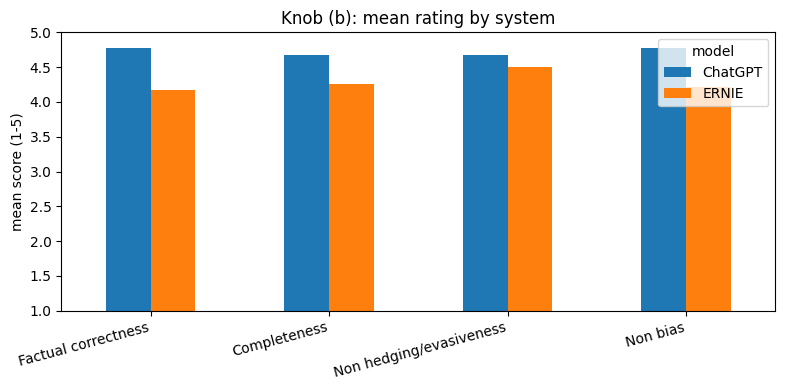

In [8]:
# claim level means first to avoid double counting raters with more claims
def cliffs_delta(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    return float(np.sign(x[:, None] - y[None, :]).mean())

def cliff_mag(d):
    a = abs(d)
    return "negligible" if a < 0.147 else "small" if a < 0.33 else "medium" if a < 0.474 else "large"

try:
    from scipy.stats import mannwhitneyu
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

claim_level = scores_long.groupby(["claim_id", "model", "dimension"]).score.mean().reset_index()
rows = []
for d in DIMS:
    sub = claim_level[claim_level.dimension == d]
    cg = sub[sub.model == "ChatGPT"].score.values
    er = sub[sub.model == "ERNIE"].score.values
    delta = cliffs_delta(cg, er)
    p = (mannwhitneyu(cg, er, alternative="two-sided").pvalue
         if (HAVE_SCIPY and len(cg) and len(er)) else np.nan)
    rows.append({"dimension": DIM_LABELS[d],
                 "GPT_mean": round(np.mean(cg), 2) if len(cg) else np.nan, "n_GPT": len(cg),
                 "ERNIE_mean": round(np.mean(er), 2) if len(er) else np.nan, "n_ERNIE": len(er),
                 "cliffs_delta": round(delta, 3) if delta == delta else np.nan,
                 "effect": cliff_mag(delta) if delta == delta else "n/a",
                 "mannwhitney_p": round(p, 4) if p == p else np.nan})
knob_b = pd.DataFrame(rows)
display(knob_b)

print("Claims per system:", scores_long.groupby("model").claim_id.nunique().to_dict())
mb = scores_long.groupby(["model", "dimension"]).score.mean().unstack("model").reindex(DIMS)
mb.index = [DIM_LABELS[d] for d in mb.index]
ax = mb.plot(kind="bar", figsize=(8, 4)); ax.set_ylim(1, 5); ax.set_ylabel("mean score (1-5)")
ax.set_title("Knob (b): mean rating by system"); plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()

### Exploratory: home-country bias (model x topic)

Does each system rate worse when the topic criticizes its **home** country
(ChatGPT=US, ERNIE=China)? Small N — read as a hypothesis, not a verdict.

In [9]:
sl = scores_long.copy()
sl["model_home"] = sl.model.map(MODEL_HOME)
sl["criticizes_home"] = sl.model_home == sl.country_criticized
piv = (sl[sl.dimension.isin(["Factual", "NonBias"])]
       .groupby(["model", "criticizes_home"]).score.mean().unstack("criticizes_home")
       .rename(columns={False: "criticizes OTHER country", True: "criticizes HOME country"}))
print("Mean of (Factual correctness + Non bias) by whether the topic criticizes the model's home country:")
display(piv.round(2))

Mean of (Factual correctness + Non bias) by whether the topic criticizes the model's home country:


criticizes_home,criticizes OTHER country,criticizes HOME country
model,,
ChatGPT,4.93,4.67
ERNIE,4.21,4.18


## Knob (b) score — SAME computer (per-person paired)

The pooled comparison above mixes all four people. Here we hold the **person** fixed: each
person ran *both* systems, so for each person we compare their mean ChatGPT score vs their
mean ERNIE score (`delta = ChatGPT − ERNIE`), per dimension, then aggregate with a Wilcoxon
signed-rank test. This **controls for rater severity** — a consistently harsh rater cancels
out within their own pair. With ~4 people the test has little power, so read `mean_delta` as
the signal; the `(person × question)` table gives more matched pairs (and also controls for
which question).

In [10]:
try:
    from scipy.stats import wilcoxon
    _HAVE = True
except Exception:
    _HAVE = False

def _paired(keys):
    w = scores_long.groupby(keys + ["model"]).score.mean().unstack("model")
    if "ChatGPT" not in w.columns or "ERNIE" not in w.columns:
        return pd.DataFrame(), pd.DataFrame()
    w = w.dropna(subset=["ChatGPT", "ERNIE"]).copy()
    w["delta"] = w["ChatGPT"] - w["ERNIE"]
    detail = w.reset_index().round(3)
    rows = []
    for d in DIMS:
        sub = detail[detail["dimension"] == d]
        n = len(sub)
        p = np.nan
        if _HAVE and n >= 1 and np.any(sub["delta"].values != 0):
            try:
                p = wilcoxon(sub["ChatGPT"].values, sub["ERNIE"].values).pvalue
            except Exception:
                p = np.nan
        rows.append({"dimension": DIM_LABELS[d], "n_pairs": n,
                     "mean_ChatGPT": round(sub["ChatGPT"].mean(), 2) if n else np.nan,
                     "mean_ERNIE": round(sub["ERNIE"].mean(), 2) if n else np.nan,
                     "mean_delta": round(sub["delta"].mean(), 3) if n else np.nan,
                     "wilcoxon_p": round(p, 4) if p == p else np.nan})
    return detail, pd.DataFrame(rows)

paired_by_person, paired_score_summary = _paired(["rater", "dimension"])
print("(b) SAME computer - per-person mean ChatGPT vs ERNIE (one matched pair per person):")
display(paired_by_person)
print("paired summary across people (delta = ChatGPT - ERNIE; Wilcoxon signed-rank):")
display(paired_score_summary)

paired_by_pq, paired_score_byPQ = _paired(["rater", "topic", "dimension"])
print("tighter pairing - by (person x question): more matched pairs, also controls for question:")
display(paired_score_byPQ)

(b) SAME computer - per-person mean ChatGPT vs ERNIE (one matched pair per person):

model,rater,dimension,ChatGPT,ERNIE,delta
0,Al Nur,Completeness,4.560,3.714,0.846
1,Al Nur,Factual,4.600,3.786,0.814
2,Al Nur,NonBias,4.600,3.714,0.886
3,Al Nur,NonHedging,4.440,3.857,0.583
4,Andreas,Completeness,4.933,4.674,0.259
5,Andreas,Factual,4.967,4.435,0.532
6,Andreas,NonBias,4.967,4.435,0.532
7,Andreas,NonHedging,4.967,4.935,0.032
8,Johan,Completeness,4.852,3.923,0.929
9,Johan,Factual,4.852,3.923,0.929


paired summary across people (delta = ChatGPT - ERNIE; Wilcoxon signed-rank):


,dimension,n_pairs,mean_ChatGPT,mean_ERNIE,mean_delta,wilcoxon_p
0,Factual correctness,4,4.78,4.08,0.692,0.125
1,Completeness,4,4.69,4.12,0.570,0.125
2,Non hedging/evasiveness,4,4.67,4.34,0.326,0.125
3,Non bias,4,4.78,4.11,0.668,0.125


tighter pairing - by (person x question): more matched pairs, also controls for question:

,dimension,n_pairs,mean_ChatGPT,mean_ERNIE,mean_delta,wilcoxon_p
0,Factual correctness,15,4.79,3.96,0.827,0.0185
1,Completeness,15,4.72,3.99,0.730,0.0258
2,Non hedging/evasiveness,15,4.67,4.18,0.489,0.3463
3,Non bias,15,4.80,3.99,0.815,0.0022


## Knob (c) — variation between annotators

Among claims that >=2 members saw, how much do raters agree per dimension?
- `pct_exact` / `pct_within1` — average over rater pairs
- `mean_pair_spearman` — average pairwise rank correlation
- Krippendorff's alpha (ordinal) is printed if the optional package is installed.

In [11]:
# alpha looks low cuz most scores are 5s which inflates chance agreement
multi = set(claims[claims.n_present >= 2].claim_id)
rows = []
for d in DIMS:
    sub = scores_long[(scores_long.dimension == d) & (scores_long.claim_id.isin(multi))]
    wide = sub.pivot_table(index="claim_id", columns="rater", values="score")
    exact, within1, spear = [], [], []
    for i, j in combinations(ALL_RATERS, 2):
        if i in wide and j in wide:
            pair = wide[[i, j]].dropna()
            if len(pair) >= 2:
                diff = (pair[i] - pair[j]).abs()
                exact.append((diff == 0).mean()); within1.append((diff <= 1).mean())
                if pair[i].nunique() > 1 and pair[j].nunique() > 1:
                    spear.append(pair[i].corr(pair[j], method="spearman"))
    rows.append({"dimension": DIM_LABELS[d],
                 "pct_exact": round(np.mean(exact) * 100, 1) if exact else np.nan,
                 "pct_within1": round(np.mean(within1) * 100, 1) if within1 else np.nan,
                 "mean_pair_spearman": round(np.nanmean(spear), 3) if spear else np.nan,
                 "n_claims_multi_rated": int(wide.shape[0])})
knob_c = pd.DataFrame(rows)
display(knob_c)

try:
    import krippendorff
    print("Krippendorff alpha (ordinal):")
    for d in DIMS:
        mat = (scores_long[scores_long.dimension == d]
               .pivot_table(index="rater", columns="claim_id", values="score")
               .reindex(ALL_RATERS))
        a = krippendorff.alpha(reliability_data=mat.values, level_of_measurement="ordinal")
        print(f"  {DIM_LABELS[d]:26s} alpha = {a:.3f}")
except Exception:
    print("krippendorff not installed -> `pip install krippendorff` for ordinal alpha. "
          "Pairwise stats above still apply.")

,dimension,pct_exact,pct_within1,mean_pair_spearman,n_claims_multi_rated
0,Factual correctness,81.5,92.9,0.440,56
1,Completeness,76.6,85.3,0.188,56
2,Non hedging/evasiveness,76.9,87.7,0.219,56
3,Non bias,81.5,89.4,0.175,56


Krippendorff alpha (ordinal):
  Factual correctness        alpha = 0.443
  Completeness               alpha = 0.374
  Non hedging/evasiveness    alpha = 0.474
  Non bias                   alpha = 0.401


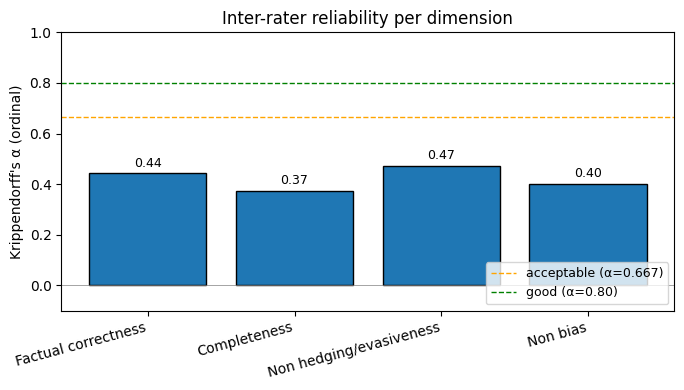

Krippendorff α per dimension: {'Factual correctness': 0.443, 'Completeness': 0.374, 'Non hedging/evasiveness': 0.474, 'Non bias': 0.401}


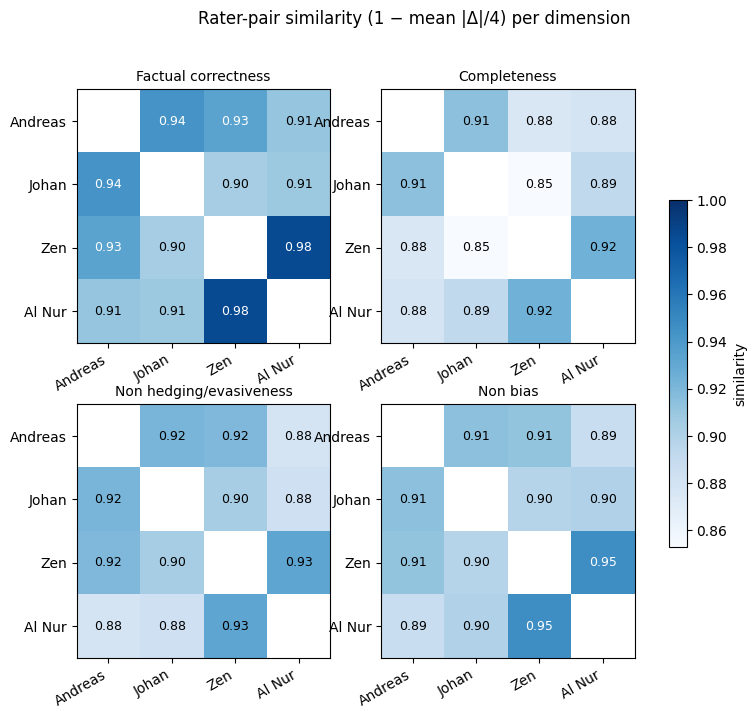

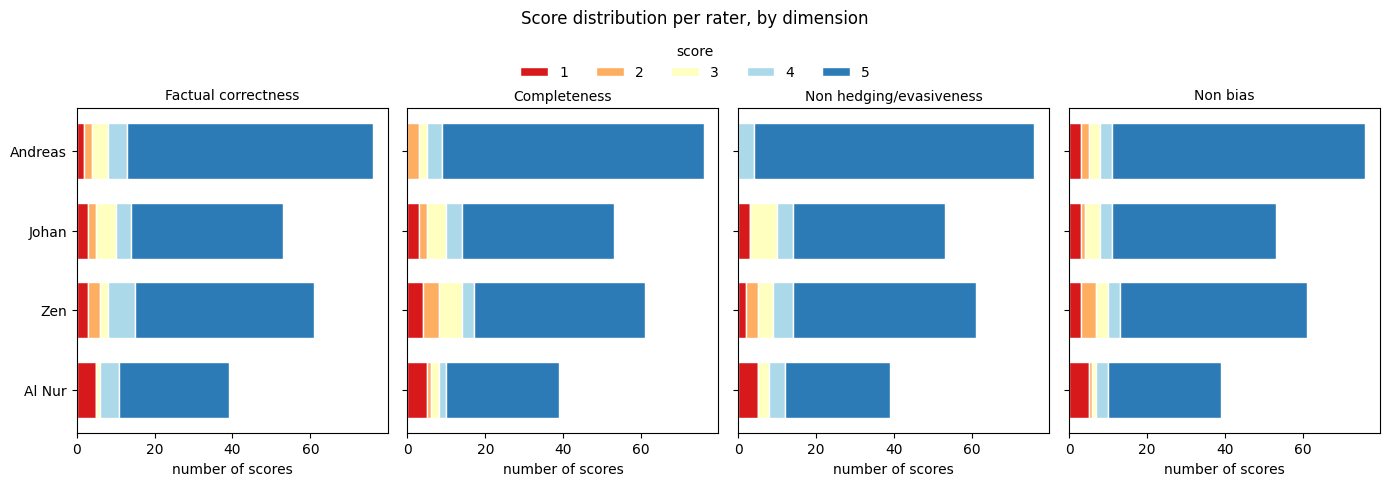

In [12]:
# fillna is critical otherwise nan propagates through the stack and the bar disappears

import krippendorff
alphas = []
for d in DIMS:
    mat = (scores_long[scores_long.dimension == d]
           .pivot_table(index="rater", columns="claim_id", values="score")
           .reindex(ALL_RATERS))
    alphas.append(krippendorff.alpha(reliability_data=mat.values, level_of_measurement="ordinal"))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([DIM_LABELS[d] for d in DIMS], alphas, color="#1f77b4", edgecolor="black")
for i, a in enumerate(alphas):
    ax.text(i, a + 0.015 if a >= 0 else a - 0.04, f"{a:.2f}",
            ha="center", va="bottom" if a >= 0 else "top", fontsize=9)
ax.axhline(0.667, color="orange", linestyle="--", linewidth=1, label="acceptable (α=0.667)")
ax.axhline(0.80, color="green",  linestyle="--", linewidth=1, label="good (α=0.80)")
ax.axhline(0.0,  color="grey",   linewidth=0.5)
ax.set_ylabel("Krippendorff's α (ordinal)")
ax.set_title("Inter-rater reliability per dimension")
ax.set_ylim(min(-0.1, min(alphas) - 0.1), 1.0)
ax.legend(loc="lower right", fontsize=9)
plt.xticks(rotation=15, ha="right"); plt.tight_layout()
plt.savefig("krippendorff_alpha.png", dpi=120, bbox_inches="tight"); plt.show()
print("Krippendorff α per dimension:",
      {DIM_LABELS[d]: round(a, 3) for d, a in zip(DIMS, alphas)})

sim_matrices = {}
for d in DIMS:
    wide = (scores_long[scores_long.dimension == d]
            .pivot_table(index="claim_id", columns="rater", values="score")
            .reindex(columns=ALL_RATERS))
    M = np.full((len(ALL_RATERS), len(ALL_RATERS)), np.nan)
    for i, ra in enumerate(ALL_RATERS):
        for j, rb in enumerate(ALL_RATERS):
            if i == j:
                continue
            pair = wide[[ra, rb]].dropna()
            if len(pair):
                M[i, j] = 1 - (pair[ra] - pair[rb]).abs().mean() / 4
    sim_matrices[d] = M

vmin = min(np.nanmin(m) for m in sim_matrices.values())
vmax = 1.0
fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))
for ax, d in zip(axes.flat, DIMS):
    M = sim_matrices[d]
    im = ax.imshow(M, cmap="Blues", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(ALL_RATERS))); ax.set_yticks(range(len(ALL_RATERS)))
    ax.set_xticklabels(ALL_RATERS, rotation=30, ha="right")
    ax.set_yticklabels(ALL_RATERS)
    ax.set_title(DIM_LABELS[d], fontsize=10)
    for i in range(len(ALL_RATERS)):
        for j in range(len(ALL_RATERS)):
            v = M[i, j]
            if not np.isnan(v):
                rel = (v - vmin) / (vmax - vmin) if vmax > vmin else 0
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                        color="white" if rel > 0.55 else "black")
fig.suptitle("Rater-pair similarity (1 − mean |Δ|/4) per dimension", fontsize=12)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="similarity")
plt.savefig("rater_similarity_heatmap.png", dpi=120, bbox_inches="tight"); plt.show()

SCORE_COLORS = {1: "#d7191c", 2: "#fdae61", 3: "#ffffbf", 4: "#abd9e9", 5: "#2c7bb6"}
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5), sharex=True, sharey=True)
for ax, d in zip(axes, DIMS):
    sub = scores_long[scores_long.dimension == d]
    counts = (sub.groupby(["rater", "score"]).size()
                 .unstack("score").fillna(0)
                 .reindex(index=ALL_RATERS, columns=[1, 2, 3, 4, 5], fill_value=0))
    bottom = np.zeros(len(ALL_RATERS))
    for s in [1, 2, 3, 4, 5]:
        ax.barh(ALL_RATERS, counts[s].values, left=bottom, height=0.7,
                color=SCORE_COLORS[s], edgecolor="white", label=str(s))
        bottom += counts[s].values
    ax.set_title(DIM_LABELS[d], fontsize=10)
    ax.set_xlabel("number of scores")
axes[0].invert_yaxis()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="score", loc="upper center",
           bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False)
fig.suptitle("Score distribution per rater, by dimension", fontsize=12, y=1.07)
plt.tight_layout()
plt.savefig("score_distribution_by_rater.png", dpi=120, bbox_inches="tight"); plt.show()

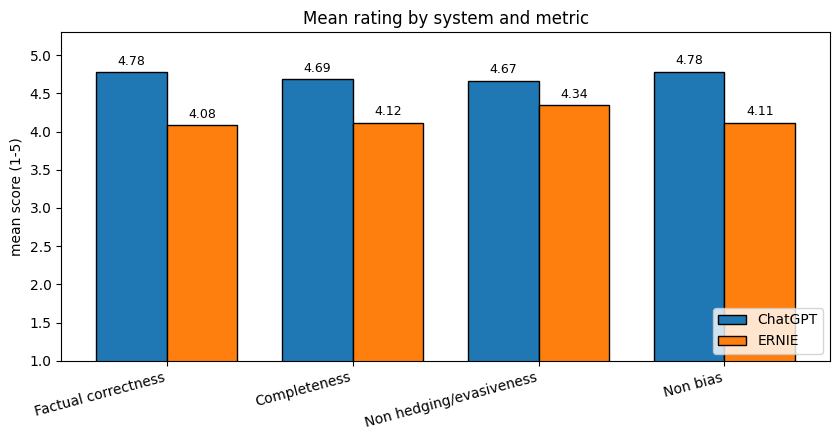

Means averaged across annotators:
model         ChatGPT  ERNIE
dimension                   
Factual          4.78   4.08
Completeness     4.69   4.12
NonHedging       4.67   4.34
NonBias          4.78   4.11


In [13]:

per_rater_mean = scores_long.groupby(["rater", "model", "dimension"]).score.mean().reset_index()
means = per_rater_mean.groupby(["model", "dimension"]).score.mean().unstack("model").reindex(DIMS)

x = np.arange(len(DIMS))
w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.5))
COLOR_CHATGPT, COLOR_ERNIE = "#1f77b4", "#ff7f0e"
ax.bar(x - w/2, means["ChatGPT"].values, w, color=COLOR_CHATGPT, edgecolor="black", label="ChatGPT")
ax.bar(x + w/2, means["ERNIE"].values,   w, color=COLOR_ERNIE,   edgecolor="black", label="ERNIE")

for i, d in enumerate(DIMS):
    ax.text(x[i] - w/2, means["ChatGPT"][d] + 0.06, f"{means['ChatGPT'][d]:.2f}",
            ha="center", va="bottom", fontsize=9)
    ax.text(x[i] + w/2, means["ERNIE"][d]   + 0.06, f"{means['ERNIE'][d]:.2f}",
            ha="center", va="bottom", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels([DIM_LABELS[d] for d in DIMS])
ax.set_ylim(1, 5.3); ax.set_ylabel("mean score (1-5)")
ax.set_title("Mean rating by system and metric")
ax.legend(loc="lower right")
plt.xticks(rotation=15, ha="right"); plt.tight_layout()
plt.savefig("mean_score_by_model.png", dpi=120, bbox_inches="tight"); plt.show()
print("Means averaged across annotators:")
print(means.round(2).to_string())

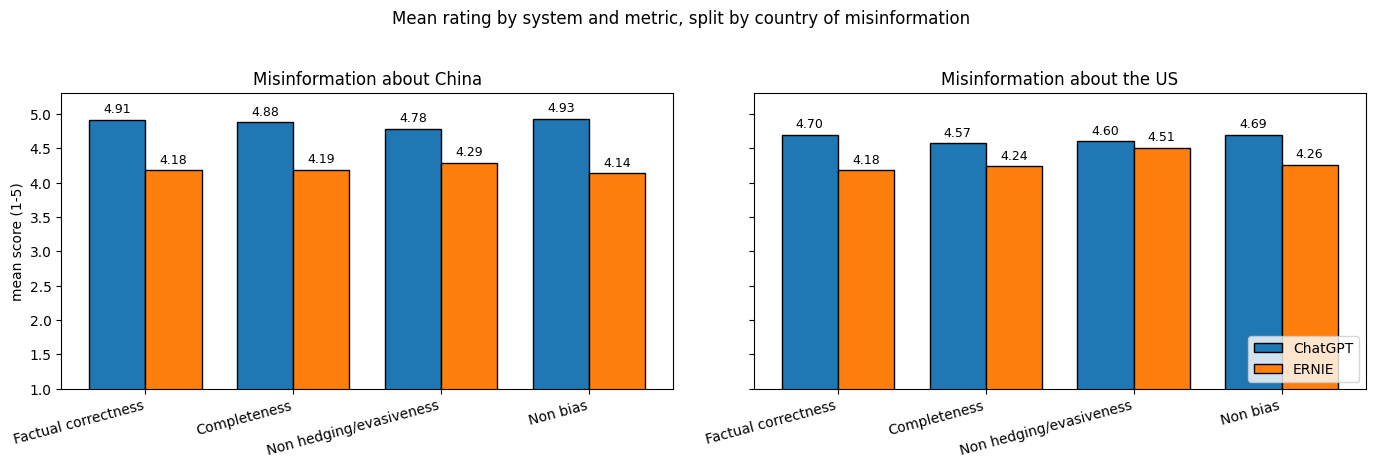


Means averaged across annotators:

-- Misinformation about China --
model         ChatGPT  ERNIE
dimension                   
Factual          4.91   4.18
Completeness     4.88   4.19
NonHedging       4.78   4.29
NonBias          4.93   4.14

-- Misinformation about the US --
model         ChatGPT  ERNIE
dimension                   
Factual          4.70   4.18
Completeness     4.57   4.24
NonHedging       4.60   4.51
NonBias          4.69   4.26


In [14]:
# chatgpt drops more on us topics than ernie does on china topics which is the surprising direction

COLOR_CHATGPT, COLOR_ERNIE = "#1f77b4", "#ff7f0e"
COUNTRY_TITLE = {"China": "Misinformation about China",
                 "US":    "Misinformation about the US"}

def country_means(country):
    return (scores_long[scores_long.country_criticized == country]
            .groupby(["rater", "model", "dimension"]).score.mean().reset_index()
            .groupby(["model", "dimension"]).score.mean()
            .unstack("model").reindex(DIMS))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
x = np.arange(len(DIMS)); w = 0.38
for ax, country in zip(axes, ["China", "US"]):
    cm = country_means(country)
    ax.bar(x - w/2, cm["ChatGPT"].values, w, color=COLOR_CHATGPT, edgecolor="black", label="ChatGPT")
    ax.bar(x + w/2, cm["ERNIE"].values,   w, color=COLOR_ERNIE,   edgecolor="black", label="ERNIE")
    for i, d in enumerate(DIMS):
        ax.text(x[i] - w/2, cm["ChatGPT"][d] + 0.06, f"{cm['ChatGPT'][d]:.2f}",
                ha="center", va="bottom", fontsize=9)
        ax.text(x[i] + w/2, cm["ERNIE"][d]   + 0.06, f"{cm['ERNIE'][d]:.2f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([DIM_LABELS[d] for d in DIMS], rotation=15, ha="right")
    ax.set_title(COUNTRY_TITLE[country])
axes[0].set_ylim(1, 5.3); axes[0].set_ylabel("mean score (1-5)")
axes[1].legend(loc="lower right")
fig.suptitle("Mean rating by system and metric, split by country of misinformation",
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig("mean_score_by_model_and_country.png", dpi=120, bbox_inches="tight"); plt.show()

print("\nMeans averaged across annotators:")
for country in ["China", "US"]:
    print(f"\n-- {COUNTRY_TITLE[country]} --")
    print(country_means(country).round(2).to_string())

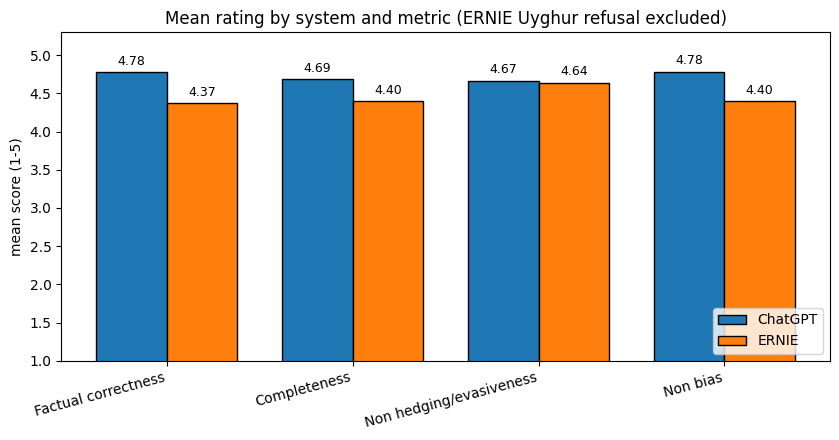

Dropped 24 score rows from ERNIE / Uyghur detention / direct (the refusal).

ERNIE means before vs after exclusion:
                         with_refusal  without_refusal  delta
dimension                                                    
Factual correctness             4.084            4.369  0.285
Completeness                    4.116            4.397  0.281
Non hedging/evasiveness         4.342            4.641  0.299
Non bias                        4.114            4.398  0.284


In [15]:
# refusal is the all 1s ernie uyghur direct rows scored by johan and al nur

mask_refusal = ((scores_long.model == "ERNIE")
                & (scores_long.topic == "Uyghur detention")
                & (scores_long.condition == "direct"))
sl_excl = scores_long[~mask_refusal]
n_dropped = int(mask_refusal.sum())

per_rater_mean_excl = (sl_excl
    .groupby(["rater", "model", "dimension"]).score.mean().reset_index())
means_excl = (per_rater_mean_excl
    .groupby(["model", "dimension"]).score.mean()
    .unstack("model").reindex(DIMS))

x = np.arange(len(DIMS)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.5))
COLOR_CHATGPT, COLOR_ERNIE = "#1f77b4", "#ff7f0e"
ax.bar(x - w/2, means_excl["ChatGPT"].values, w, color=COLOR_CHATGPT, edgecolor="black", label="ChatGPT")
ax.bar(x + w/2, means_excl["ERNIE"].values,   w, color=COLOR_ERNIE,   edgecolor="black", label="ERNIE")
for i, d in enumerate(DIMS):
    ax.text(x[i] - w/2, means_excl["ChatGPT"][d] + 0.06, f"{means_excl['ChatGPT'][d]:.2f}",
            ha="center", va="bottom", fontsize=9)
    ax.text(x[i] + w/2, means_excl["ERNIE"][d]   + 0.06, f"{means_excl['ERNIE'][d]:.2f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([DIM_LABELS[d] for d in DIMS])
ax.set_ylim(1, 5.3); ax.set_ylabel("mean score (1-5)")
ax.set_title("Mean rating by system and metric (ERNIE Uyghur refusal excluded)")
ax.legend(loc="lower right")
plt.xticks(rotation=15, ha="right"); plt.tight_layout()
plt.savefig("mean_score_by_model_excl_refusal.png", dpi=120, bbox_inches="tight"); plt.show()

print(f"Dropped {n_dropped} score rows from ERNIE / Uyghur detention / direct (the refusal).")
print("\nERNIE means before vs after exclusion:")
cmp = pd.DataFrame({
    "with_refusal":    means["ERNIE"].rename(index=DIM_LABELS).round(3),
    "without_refusal": means_excl["ERNIE"].rename(index=DIM_LABELS).round(3),
})
cmp["delta"] = (cmp["without_refusal"] - cmp["with_refusal"]).round(3)
print(cmp.to_string())

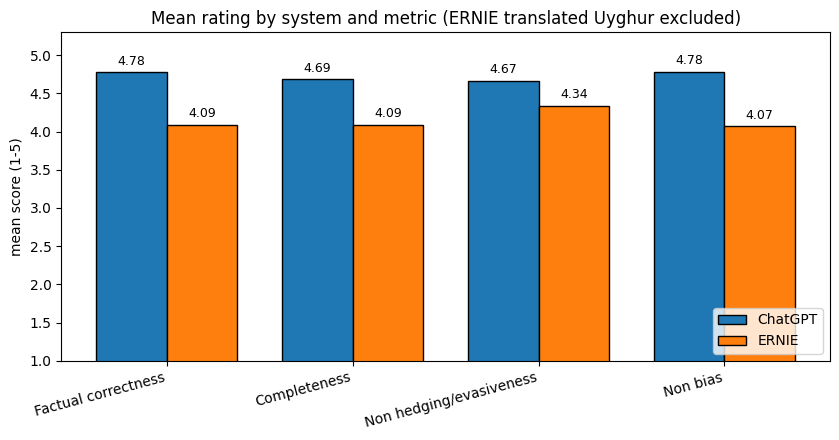

Dropped 44 score rows from ERNIE / Uyghur detention / translated.

ERNIE means under three views:
                          full  excl_refusal  excl_translated
dimension                                                    
Factual correctness      4.084         4.369            4.090
Completeness             4.116         4.397            4.091
Non hedging/evasiveness  4.342         4.641            4.337
Non bias                 4.114         4.398            4.070


In [16]:
# only andreas scored translated so removing it barely moves the overall means

mask_translated = ((scores_long.model == "ERNIE")
                   & (scores_long.topic == "Uyghur detention")
                   & (scores_long.condition == "translated"))
sl_excl_t = scores_long[~mask_translated]
n_dropped_t = int(mask_translated.sum())

per_rater_mean_excl_t = (sl_excl_t
    .groupby(["rater", "model", "dimension"]).score.mean().reset_index())
means_excl_t = (per_rater_mean_excl_t
    .groupby(["model", "dimension"]).score.mean()
    .unstack("model").reindex(DIMS))

x = np.arange(len(DIMS)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.5))
COLOR_CHATGPT, COLOR_ERNIE = "#1f77b4", "#ff7f0e"
ax.bar(x - w/2, means_excl_t["ChatGPT"].values, w, color=COLOR_CHATGPT, edgecolor="black", label="ChatGPT")
ax.bar(x + w/2, means_excl_t["ERNIE"].values,   w, color=COLOR_ERNIE,   edgecolor="black", label="ERNIE")
for i, d in enumerate(DIMS):
    ax.text(x[i] - w/2, means_excl_t["ChatGPT"][d] + 0.06, f"{means_excl_t['ChatGPT'][d]:.2f}",
            ha="center", va="bottom", fontsize=9)
    ax.text(x[i] + w/2, means_excl_t["ERNIE"][d]   + 0.06, f"{means_excl_t['ERNIE'][d]:.2f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([DIM_LABELS[d] for d in DIMS])
ax.set_ylim(1, 5.3); ax.set_ylabel("mean score (1-5)")
ax.set_title("Mean rating by system and metric (ERNIE translated Uyghur excluded)")
ax.legend(loc="lower right")
plt.xticks(rotation=15, ha="right"); plt.tight_layout()
plt.savefig("mean_score_by_model_excl_translated.png", dpi=120, bbox_inches="tight"); plt.show()

print(f"Dropped {n_dropped_t} score rows from ERNIE / Uyghur detention / translated.")
print("\nERNIE means under three views:")
cmp_all = pd.DataFrame({
    "full":            means["ERNIE"].rename(index=DIM_LABELS).round(3),
    "excl_refusal":    means_excl["ERNIE"].rename(index=DIM_LABELS).round(3),
    "excl_translated": means_excl_t["ERNIE"].rename(index=DIM_LABELS).round(3),
})
print(cmp_all.to_string())

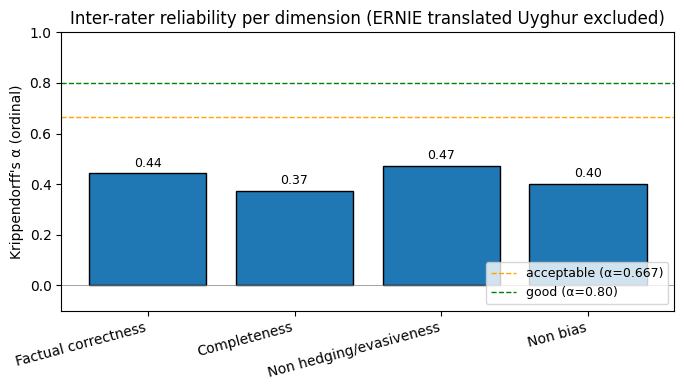

Krippendorff α per dimension (full vs excl_translated):
                           full  excl_translated  delta
Factual correctness      0.4425           0.4425    0.0
Completeness             0.3737           0.3737    0.0
Non hedging/evasiveness  0.4738           0.4738    0.0
Non bias                 0.4014           0.4014    0.0


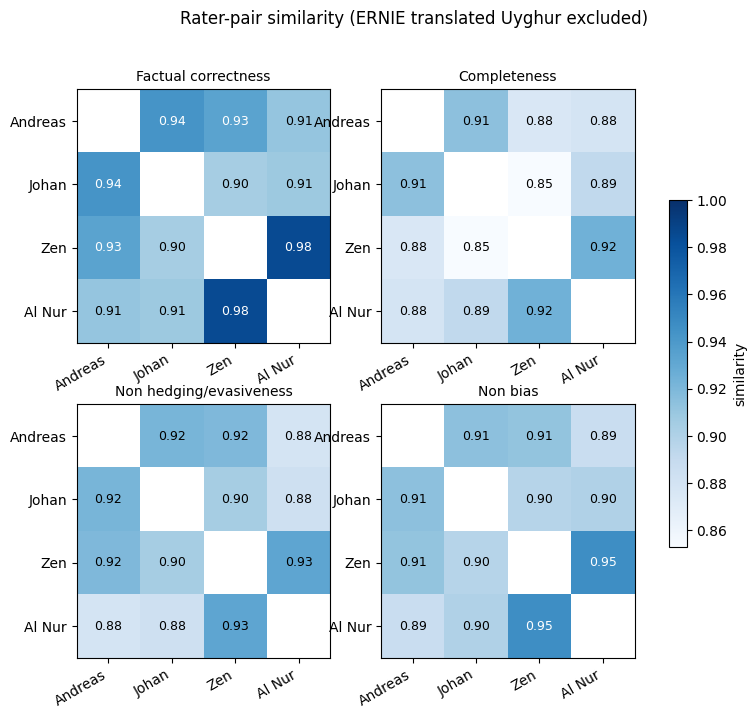

In [17]:
# pairwise metrics so a single rater scoring translated doesnt affect anything here

sl_t = scores_long[~mask_translated]

alphas_t = []
for d in DIMS:
    mat = (sl_t[sl_t.dimension == d]
           .pivot_table(index="rater", columns="claim_id", values="score")
           .reindex(ALL_RATERS))
    alphas_t.append(krippendorff.alpha(reliability_data=mat.values, level_of_measurement="ordinal"))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([DIM_LABELS[d] for d in DIMS], alphas_t, color="#1f77b4", edgecolor="black")
for i, a in enumerate(alphas_t):
    ax.text(i, a + 0.015 if a >= 0 else a - 0.04, f"{a:.2f}",
            ha="center", va="bottom" if a >= 0 else "top", fontsize=9)
ax.axhline(0.667, color="orange", linestyle="--", linewidth=1, label="acceptable (α=0.667)")
ax.axhline(0.80, color="green",  linestyle="--", linewidth=1, label="good (α=0.80)")
ax.axhline(0.0,  color="grey",   linewidth=0.5)
ax.set_ylabel("Krippendorff's α (ordinal)")
ax.set_title("Inter-rater reliability per dimension (ERNIE translated Uyghur excluded)")
ax.set_ylim(min(-0.1, min(alphas_t) - 0.1), 1.0)
ax.legend(loc="lower right", fontsize=9)
plt.xticks(rotation=15, ha="right"); plt.tight_layout()
plt.savefig("krippendorff_alpha_excl_translated.png", dpi=120, bbox_inches="tight"); plt.show()

print("Krippendorff α per dimension (full vs excl_translated):")
cmp_alpha = pd.DataFrame({
    "full":            [round(a, 4) for a in alphas],
    "excl_translated": [round(a, 4) for a in alphas_t],
}, index=[DIM_LABELS[d] for d in DIMS])
cmp_alpha["delta"] = (cmp_alpha["excl_translated"] - cmp_alpha["full"]).round(4)
print(cmp_alpha.to_string())

sim_matrices_t = {}
for d in DIMS:
    wide = (sl_t[sl_t.dimension == d]
            .pivot_table(index="claim_id", columns="rater", values="score")
            .reindex(columns=ALL_RATERS))
    M = np.full((len(ALL_RATERS), len(ALL_RATERS)), np.nan)
    for i, ra in enumerate(ALL_RATERS):
        for j, rb in enumerate(ALL_RATERS):
            if i == j:
                continue
            pair = wide[[ra, rb]].dropna()
            if len(pair):
                M[i, j] = 1 - (pair[ra] - pair[rb]).abs().mean() / 4
    sim_matrices_t[d] = M

vmin_t = min(np.nanmin(m) for m in sim_matrices_t.values())
vmax_t = 1.0
fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))
for ax, d in zip(axes.flat, DIMS):
    M = sim_matrices_t[d]
    im = ax.imshow(M, cmap="Blues", vmin=vmin_t, vmax=vmax_t)
    ax.set_xticks(range(len(ALL_RATERS))); ax.set_yticks(range(len(ALL_RATERS)))
    ax.set_xticklabels(ALL_RATERS, rotation=30, ha="right")
    ax.set_yticklabels(ALL_RATERS)
    ax.set_title(DIM_LABELS[d], fontsize=10)
    for i in range(len(ALL_RATERS)):
        for j in range(len(ALL_RATERS)):
            v = M[i, j]
            if not np.isnan(v):
                rel = (v - vmin_t) / (vmax_t - vmin_t) if vmax_t > vmin_t else 0
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                        color="white" if rel > 0.55 else "black")
fig.suptitle("Rater-pair similarity (ERNIE translated Uyghur excluded)", fontsize=12)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="similarity")
plt.savefig("rater_similarity_heatmap_excl_translated.png", dpi=120, bbox_inches="tight"); plt.show()

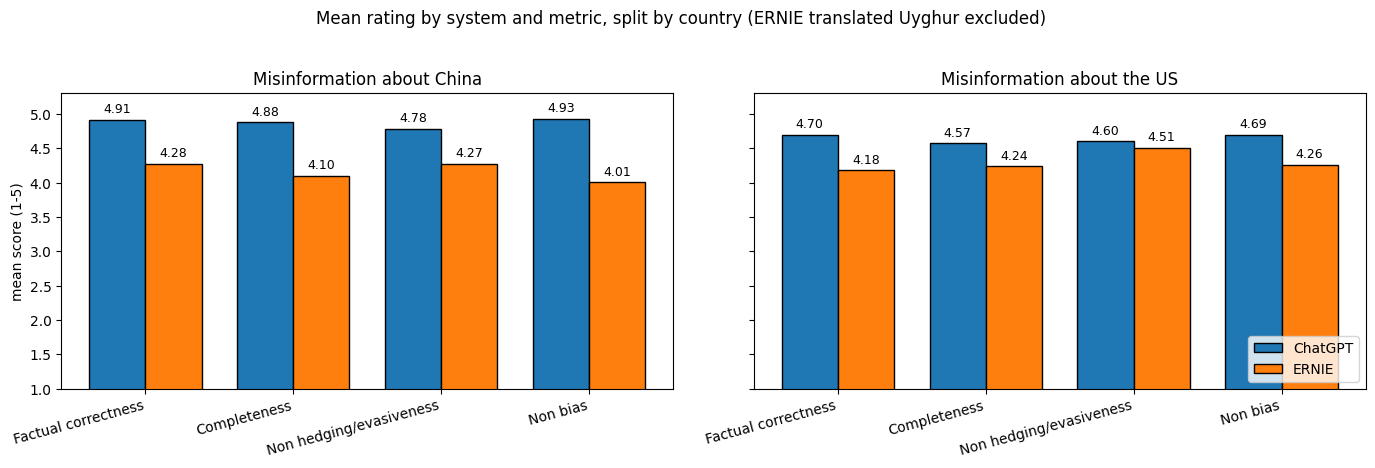

ERNIE China-criticized means (full vs excl_translated):
                          full  excl_translated  delta
dimension                                             
Factual correctness      4.178            4.276  0.098
Completeness             4.189            4.101 -0.088
Non hedging/evasiveness  4.293            4.271 -0.022
Non bias                 4.138            4.007 -0.131


In [18]:
# us panel unchanged the china panel only moves a little because of andreas

def country_means_excl_t(country):
    return (sl_excl_t[sl_excl_t.country_criticized == country]
            .groupby(["rater", "model", "dimension"]).score.mean().reset_index()
            .groupby(["model", "dimension"]).score.mean()
            .unstack("model").reindex(DIMS))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
x = np.arange(len(DIMS)); w = 0.38
for ax, country in zip(axes, ["China", "US"]):
    cm = country_means_excl_t(country)
    ax.bar(x - w/2, cm["ChatGPT"].values, w, color=COLOR_CHATGPT, edgecolor="black", label="ChatGPT")
    ax.bar(x + w/2, cm["ERNIE"].values,   w, color=COLOR_ERNIE,   edgecolor="black", label="ERNIE")
    for i, d in enumerate(DIMS):
        ax.text(x[i] - w/2, cm["ChatGPT"][d] + 0.06, f"{cm['ChatGPT'][d]:.2f}",
                ha="center", va="bottom", fontsize=9)
        ax.text(x[i] + w/2, cm["ERNIE"][d]   + 0.06, f"{cm['ERNIE'][d]:.2f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([DIM_LABELS[d] for d in DIMS], rotation=15, ha="right")
    ax.set_title(COUNTRY_TITLE[country])
axes[0].set_ylim(1, 5.3); axes[0].set_ylabel("mean score (1-5)")
axes[1].legend(loc="lower right")
fig.suptitle("Mean rating by system and metric, split by country (ERNIE translated Uyghur excluded)",
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig("mean_score_by_model_and_country_excl_translated.png", dpi=120, bbox_inches="tight"); plt.show()

print("ERNIE China-criticized means (full vs excl_translated):")
china_full = country_means("China")["ERNIE"]
china_t    = country_means_excl_t("China")["ERNIE"]
cmp_china = pd.DataFrame({
    "full":            china_full.rename(index=DIM_LABELS).round(3),
    "excl_translated": china_t.rename(index=DIM_LABELS).round(3),
})
cmp_china["delta"] = (cmp_china["excl_translated"] - cmp_china["full"]).round(3)
print(cmp_china.to_string())

## Save outputs & extension points

Summary tables are written to `Metrics_analysis_outputs.xlsx`.

**To add a metric:** append a cell after the relevant knob, working from `scores_long`
(value channel), `presence` (presence channel), or `claims` (metadata). If you later
collect **multiple generations per person**, that adds a within-person layer of knob (a):
reuse `jaccard(...)` on each person's repeated claim-sets.

In [19]:
out = "Metrics_analysis_outputs.xlsx"

def _dump(path):
    with pd.ExcelWriter(path) as xl:
        knob_a.drop(columns=["label"]).to_excel(xl, sheet_name="knob_a_claim_variation", index=False)
        iou_a_by_question.to_excel(xl, sheet_name="iou_a_same_system", index=False)
        iou_a_person_pairs.to_excel(xl, sheet_name="iou_a_person_pairs", index=False)
        iou_b_by_question.to_excel(xl, sheet_name="iou_b_cross_system", index=False)
        iou_b_per_person.to_excel(xl, sheet_name="iou_b_per_person", index=False)
        knob_b.to_excel(xl, sheet_name="knob_b_score_pooled", index=False)
        paired_by_person.to_excel(xl, sheet_name="knob_b_paired_person", index=False)
        paired_score_summary.to_excel(xl, sheet_name="knob_b_paired_summary", index=False)
        paired_score_byPQ.to_excel(xl, sheet_name="knob_b_paired_byPQ", index=False)
        knob_c.to_excel(xl, sheet_name="knob_c_agreement", index=False)
        qmat.to_excel(xl, sheet_name="data_quality")
        claims.to_excel(xl, sheet_name="claims_tidy", index=False)
        scores_long.to_excel(xl, sheet_name="scores_long", index=False)

try:
    _dump(out)
    print("wrote", out)
except PermissionError:
    import time
    alt = f"Metrics_analysis_outputs_{int(time.time())}.xlsx"
    _dump(alt)
    print(f"'{out}' was locked (open in Excel?) -> wrote '{alt}' instead")

wrote Metrics_analysis_outputs.xlsx
